# Week 11 — Evaluate empirical-distribution diffusion (11d)

Eval-only counterpart to `11c_train_empirical.ipynb`. Scores every
`ckpt_emp_E*.ckpt` against the classical NLL baseline using the same
per-window evaluation blocks and the same `mu_0(A)` hard gate as the residual
evaluation in `11b_evaluate.ipynb`, so the empirical-target NLL is directly
comparable to the residual-target NLL and to the classical NLL.

Three things make this notebook simpler than 11b:

1. Sampled densities live on the simplex by construction — no `+ log Z`
   normalizer, no zero-integral projection, no floor-clamping leak. The
   `nll_norm` / `nll_norm_proj` distinction in 11b collapses to a single
   well-defined `nll_direct`.
2. There is no `+ p_classical` decomposition at score time — the model
   already predicts the full distribution.
3. The oracle (`OracleMLP`) is reused from `evaluation.py` unchanged; it now
   maps cond to a per-bin Gaussian over standardized **logits** rather than
   standardized residuals, so its NLL is interpreted on the same target the
   diffusion is trying to predict — apples-to-apples.

> The **test split is reserved for the PI**. Every data-loading cell filters
> to `split in {'train', 'val'}`.

In [1]:
import os, subprocess, sys

repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()

There is no tracking information for the current branch.
Please specify which branch you want to merge with.
See git-pull(1) for details.

    git pull <remote> <branch>

If you wish to set tracking information for this branch you can do so with:

    git branch --set-upstream-to=origin/<branch> feature/week11



git pull skipped: Command '['git', '-C', '../../', 'pull']' returned non-zero exit status 1.
  Installing from /d0/amunozj/git_repos/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : cuda
   Seed     : 42


{'in_colab': False,
 'device': device(type='cuda'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [2]:
%load_ext autoreload
%autoreload 2

import os, sys, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import norm as sp_norm
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
_week09_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_09"))
_week10_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_10"))
_week11_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_11"))
for _p in (_week09_dir, _week11_dir, _week10_dir):
    if _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("conditioned_infrastructure", None)

from conditioned_infrastructure import find_week10_artifacts
paths = find_week10_artifacts(extra_required=[
    "data/composite_sunspot_groups_peak_area.csv",
])
if _week11_dir in sys.path:
    sys.path.remove(_week11_dir)
sys.path.insert(0, _week11_dir)
sys.modules.pop("conditioned_infrastructure", None)
sys.modules.pop("empirical_infrastructure", None)

from unconditioned_infrastructure import make_cosine_schedule
from conditioned_infrastructure import (
    block_cond_concat,
    k_run_combined,
)
from butterflAI_model import ButterflAIModel
from evaluation import (
    hard_nll_classical,
    build_eval_hemicycles,
    OracleMLP, fit_oracle, gaussian_nll,
    assemble_butterfly, butterfly_physical_checks, hemispheric_symmetry,
)
from empirical_infrastructure import (
    load_trained_empirical_experiment,
    sample_empirical_extended,
    discover_emp_experiment_checkpoints,
    hard_nll_direct,
    EMP_CKPT_PREFIX,
)

_WEEK10_DIR = paths["week10_dir"]
PARQUET_V2  = os.path.join(_WEEK10_DIR, "diffusion_windows_v2.parquet")
CKPT_DIR    = _WEEK10_DIR
classical   = ButterflAIModel(paths["classical_weights"])

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

T = 200
alpha_np, sigma_np, _ = make_cosine_schedule(T=T, s=0.008)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

windows_v2 = pd.read_parquet(PARQUET_V2)
windows_v2 = windows_v2.loc[windows_v2["split"].isin(["train", "val"])].reset_index(drop=True)
windows_aug = windows_v2
print(f"v2 parquet rows (train+val): {len(windows_v2)}")
print(f"device                     : {device}")

v2 parquet rows (train+val): 287
device                     : cuda


In [4]:
# Per-window evaluation blocks — same builder, same hard gate, same group
# tagging as 11b. The included-block set will match exactly, so the
# empirical-target NLL is directly comparable to the residual-target NLL
# from 11b's scoreboard.
hemicycles, GROUP_COLS = build_eval_hemicycles(
    raw_csv_path=paths["raw_csv"],
    windows_v2=windows_v2,
    classical=classical,
    splits=("train", "val"),
)
val_hcs = [hc for hc in hemicycles if hc["split"] == "val"]

nll_cl_val, det_cl_val = hard_nll_classical(classical, val_hcs)
print(f"val hemicycles: {len(val_hcs)} "
      f"({sum(len(hc['blocks']) for hc in val_hcs)} blocks)")
print(f"classical hard NLL (val): {nll_cl_val:.4f}  "
      f"(coverage {det_cl_val['coverage']:.3f})")

val hemicycles: 4 (55 blocks)
classical hard NLL (val): 3.2396  (coverage 1.000)


## Experiment registry

Must mirror `EXPERIMENTS_EMP` from `11c_train_empirical.ipynb`. The scoring
loop looks up each discovered `ckpt_emp_E*.ckpt` here to recover its
`consumed_keys`, architecture, and KL/smoothing knobs. If you add a variant
in the training notebook, copy its entry here too.

In [25]:
_BASE_TEMPLATE = {
    "arch":           "concat",
    "consumed_keys":  ["cond_base"],
    "groups":         ["base"],
    "hidden_dim":     128,
    "n_layers":       3,
    "fourier":        False,
    "cond_dropout_p": 0.0,
    "max_epochs":     20000,
    "lr":             1e-3,
    "batch_size":     64,
    "lambda_kl":      0.1,
    "alpha_smooth":   1.0,
    "n_pseudo_obs":   30.0,
}

def _spec(**overrides):
    d = dict(_BASE_TEMPLATE); d.update(overrides); return d

EXPERIMENTS_EMP = {
    "E0": _spec(),
    # Add E1..En entries here to match the training notebook.
    # Uncomment to add variants. Same patterns as the residual EXPERIMENTS dict.
    "E1": _spec(consumed_keys=["cond_base", "cond_cyclehemi"],
                groups=["base", "cyclehemi"]),
    "E2": _spec(consumed_keys=["cond_base", "cond_opp"],
                groups=["base", "opp"]),
    "E3": _spec(consumed_keys=["cond_base", "cond_traj"],
                groups=["base", "traj"]),
    "E4": _spec(arch="film"),
    "E5": _spec(arch="film",
                consumed_keys=["cond_base", "cond_opp"],
                groups=["base", "opp"]),
    "E6_cfg": _spec(arch="film",
                    consumed_keys=["cond_base", "cond_opp"],
                    groups=["base", "opp"],
                    cond_dropout_p=0.1),
    "E7_fourier": _spec(arch="film", fourier=True,
                        consumed_keys=["cond_base", "cond_opp"],
                        groups=["base", "opp"]),

}
for name, cfg in EXPERIMENTS_EMP.items():
    print(f"{name}: arch={cfg['arch']:6s}  consumed={cfg['consumed_keys']}  "
          f"lambda_kl={cfg['lambda_kl']}")

E0: arch=concat  consumed=['cond_base']  lambda_kl=0.1
E1: arch=concat  consumed=['cond_base', 'cond_cyclehemi']  lambda_kl=0.1
E2: arch=concat  consumed=['cond_base', 'cond_opp']  lambda_kl=0.1
E3: arch=concat  consumed=['cond_base', 'cond_traj']  lambda_kl=0.1
E4: arch=film    consumed=['cond_base']  lambda_kl=0.1
E5: arch=film    consumed=['cond_base', 'cond_opp']  lambda_kl=0.1
E6_cfg: arch=film    consumed=['cond_base', 'cond_opp']  lambda_kl=0.1
E7_fourier: arch=film    consumed=['cond_base', 'cond_opp']  lambda_kl=0.1


## Score every checkpoint

Per discovered `ckpt_emp_*.ckpt`:

1. Build per-experiment cond tensors via `block_cond_concat` (reused from
   the residual harness — unchanged behavior).
2. Sample K=100 conditional densities per val block via
   `sample_empirical_extended`. For CFG variants (`cond_dropout_p > 0`),
   sweep `guidance_w ∈ CFG_GUIDANCE_W`.
3. Fit an `OracleMLP` on `(cond, standardized logits)` pairs from the
   training set; sample K logits per val block, decode via softmax, score
   under `hard_nll_direct`.
4. Score the diffusion samples under `hard_nll_direct` (classical's hard
   gate applied so the block set matches the residual experiments).

Simplex sanity check at the top of the function asserts that every sampled
density is non-negative and integrates to 1 to float32 precision.

In [26]:
K = 100
CFG_GUIDANCE_W = [1.0, 1.5, 2.0, 3.0]

def _simplex_sanity(samples_NK15, bin_width=BIN_WIDTH):
    """Assert non-negativity + integrate-to-1 on every (15,) density vector.
    Catches a corrupted decoder before it pollutes the scoreboard."""
    nonneg = samples_NK15.min()
    mass   = samples_NK15.sum(axis=-1) * bin_width
    err    = np.abs(mass - 1.0).max()
    assert nonneg >= -1e-6, f"simplex check failed: min density = {nonneg}"
    assert err     <  1e-4, f"simplex check failed: max |Σp·Δℓ - 1| = {err}"
    return {"min_density": float(nonneg), "max_mass_err": float(err)}


def score_checkpoint_empirical(name, cfg):
    """Score one empirical-target experiment against classical + oracle.
    
    Returns a list of dicts (one per guidance weight). Keys:
    {experiment, guidance_w,
     nll_direct_mean, nll_direct_std,           # diffusion NLL on simplex
     oracle_nll_direct_mean,                    # oracle floor on simplex
     oracle_gauss,                              # oracle val Gaussian NLL on logits
     min_density, max_mass_err,                 # simplex sanity
     coverage}.
    """
    lit, train_ds, val_ds, total_dim = load_trained_empirical_experiment(
        name=name, cfg=cfg, windows_aug=windows_aug,
        classical=classical, bin_centers=BIN_CENTERS,
        ckpt_dir=CKPT_DIR, alpha_np=alpha_np, sigma_np=sigma_np,
        bin_width=BIN_WIDTH,
    )

    keys, cond_tensor = block_cond_concat(val_hcs, lit, cfg, train_ds)
    N = cond_tensor.shape[0]

    # Oracle on (cond, standardized logits).
    train_cond = torch.stack([
        torch.cat([train_ds[i][k] for k in cfg["consumed_keys"]], dim=-1)
        for i in range(len(train_ds))
    ])
    train_r = torch.stack([train_ds[i]["r_clean"] for i in range(len(train_ds))])
    val_cond = torch.stack([
        torch.cat([val_ds[i][k] for k in cfg["consumed_keys"]], dim=-1)
        for i in range(len(val_ds))
    ])
    val_r = torch.stack([val_ds[i]["r_clean"] for i in range(len(val_ds))])
    oracle_model, oracle_gauss = fit_oracle(train_cond, train_r, val_cond, val_r)

    oracle_model.eval()
    with torch.no_grad():
        o_mean, o_log_std = oracle_model(cond_tensor)
    o_std = torch.exp(o_log_std)
    torch.manual_seed(0)
    oracle_std_samples = (
        o_mean.unsqueeze(1)
        + o_std.unsqueeze(1) * torch.randn(N, K, 15)
    )
    # De-standardize logits, softmax, /bin_width → density.
    lm = train_ds.logit_means
    ls = train_ds.logit_stds
    oracle_logits = oracle_std_samples * ls + lm
    oracle_phys   = (torch.softmax(oracle_logits, dim=-1) / BIN_WIDTH).numpy()
    _simplex_sanity(oracle_phys)
    oracle_nlls, _ = k_run_combined(
        hard_nll_direct, classical, val_hcs, keys, oracle_phys,
    )

    is_cfg = cfg.get("cond_dropout_p", 0.0) > 0
    guidance_ws = CFG_GUIDANCE_W if is_cfg else [0.0]

    results = []
    for w in guidance_ws:
        cond_K = cond_tensor.repeat_interleave(K, dim=0)
        torch.manual_seed(0)
        samples_flat = sample_empirical_extended(
            lit, cond_K, guidance_w=w, bin_width=BIN_WIDTH, device=device,
        ).cpu().numpy()
        samples_NK15 = samples_flat.reshape(N, K, 15)
        sanity = _simplex_sanity(samples_NK15)

        nlls, _ = k_run_combined(
            hard_nll_direct, classical, val_hcs, keys, samples_NK15,
        )

        results.append({
            "experiment":              name,
            "guidance_w":              w,
            "nll_direct_mean":         nlls.mean(),
            "nll_direct_std":          nlls.std(),
            "oracle_nll_direct_mean":  oracle_nlls.mean(),
            "oracle_gauss":            oracle_gauss,
            "min_density":             sanity["min_density"],
            "max_mass_err":            sanity["max_mass_err"],
            "coverage":                det_cl_val["coverage"],
        })
    return results

In [27]:
_ckpts   = discover_emp_experiment_checkpoints(CKPT_DIR)
_known   = [name for name in _ckpts if name in EXPERIMENTS_EMP]
_unknown = [name for name in _ckpts if name not in EXPERIMENTS_EMP]
if _unknown:
    print(f"WARNING: skipping checkpoints with no EXPERIMENTS_EMP entry: {_unknown}")
print(f"scoring empirical checkpoints: {_known}")

all_rows = []
for name in _known:
    print(f"scoring {name} ...")
    all_rows.extend(score_checkpoint_empirical(name, EXPERIMENTS_EMP[name]))

scoreboard = pd.DataFrame(all_rows)
scoreboard["classical"] = nll_cl_val
print(scoreboard.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

scoring empirical checkpoints: ['E0', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6_cfg', 'E7_fourier']
scoring E0 ...
scoring E1 ...
scoring E2 ...
scoring E3 ...
scoring E4 ...
scoring E5 ...
scoring E6_cfg ...
scoring E7_fourier ...
experiment  guidance_w  nll_direct_mean  nll_direct_std  oracle_nll_direct_mean  oracle_gauss  min_density  max_mass_err  coverage  classical
        E0      0.0000           3.4162          0.0528                  3.3707       13.9543       0.0000        0.0000    1.0000     3.2396
        E1      0.0000           3.3726          0.0126                  3.3795       13.7497       0.0000        0.0000    1.0000     3.2396
        E2      0.0000           3.4128          0.0248                  3.3792       14.7215       0.0000        0.0000    1.0000     3.2396
        E3      0.0000           3.3970          0.0209                  3.3692       14.8572       0.0000        0.0000    1.0000     3.2396
        E4      0.0000           3.5658          0.0896           

## Headline plot

Bar chart, val split: classical baseline plus each empirical-diffusion
variant's NLL, with K-σ error bars. Oracle NLL per experiment overlaid as a
dashed horizontal marker — same interpretation as 11b's oracle floor, but on
the new (logit) target.

Reading the result:

- `nll_direct_mean < classical` → empirical-target framing solved the problem
  the residual framing couldn't (primary positive result).
- `oracle_nll_direct_mean < classical` while `nll_direct_mean ≈ classical` →
  cond now carries information about the target, but the diffusion isn't
  extracting it — architecture bottleneck, try FiLM / Fourier / longer
  training.
- `oracle_nll_direct_mean ≈ classical` → the empirical target was the
  bottleneck *for this cond set*, but switching targets alone wasn't enough;
  add cond groups.

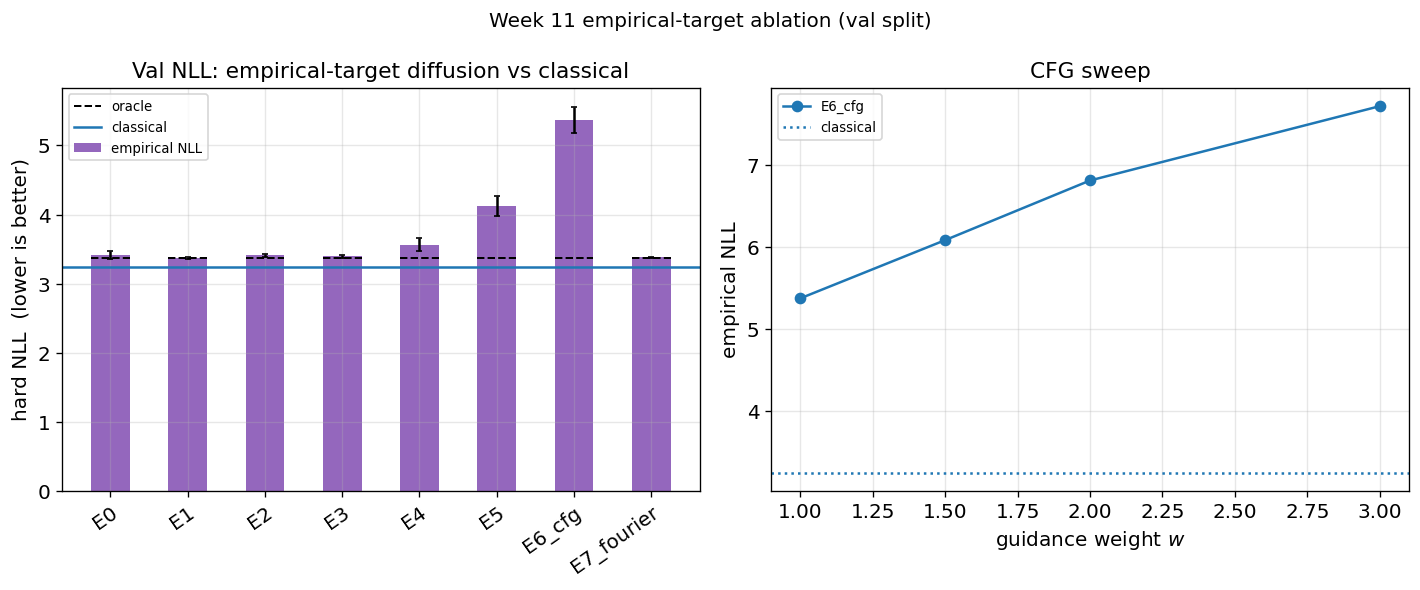

In [28]:
best_idx  = scoreboard.groupby("experiment")["nll_direct_mean"].idxmin()
best_rows = scoreboard.loc[best_idx].reset_index(drop=True)

has_cfg = (scoreboard["guidance_w"] > 0.0).any()
n_panels = 2 if has_cfg else 1
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), squeeze=False)
axes = axes[0]

ax1 = axes[0]
labels = list(best_rows["experiment"])
xr = np.arange(len(labels))
wbar = 0.5
ax1.bar(xr, best_rows["nll_direct_mean"], wbar,
        yerr=best_rows["nll_direct_std"], color="C4", capsize=2,
        label="empirical NLL")
for i, (_, row) in enumerate(best_rows.iterrows()):
    ax1.plot([i - wbar / 2, i + wbar / 2],
             [row["oracle_nll_direct_mean"]] * 2,
             "k--", lw=1.2, label="oracle" if i == 0 else None)
ax1.axhline(nll_cl_val, color="C0", lw=1.5, label="classical")
ax1.set_xticks(xr)
ax1.set_xticklabels(labels, rotation=35, ha="right", rotation_mode="anchor")
ax1.set_ylabel("hard NLL  (lower is better)")
ax1.set_title("Val NLL: empirical-target diffusion vs classical")
ax1.legend(fontsize=8)

if has_cfg:
    ax2 = axes[1]
    cfg_rows = scoreboard[scoreboard["guidance_w"] > 0.0]
    for exp_name, grp in cfg_rows.groupby("experiment"):
        grp = grp.sort_values("guidance_w")
        ax2.plot(grp["guidance_w"], grp["nll_direct_mean"], marker="o",
                 label=exp_name)
    ax2.axhline(nll_cl_val, color="C0", ls=":", label="classical")
    ax2.set_xlabel("guidance weight $w$")
    ax2.set_ylabel("empirical NLL")
    ax2.set_title("CFG sweep")
    ax2.legend(fontsize=8)

fig.suptitle("Week 11 empirical-target ablation (val split)", fontsize=12)
fig.tight_layout()
plt.show()

## Physical plausibility

NLL — even on a properly normalized simplex — only scores density at the
observed latitudes. It can't tell you whether the *generated* distribution is
physically sensible. We stack each variant's per-window densities into a
latitude-vs-time **butterfly diagram** and run the same checks as 11b
(Spörer drift, in-band mass, hemispheric symmetry). Unlike 11b there is no
`+ p_classical` step — the densities go in directly.

Note: `assemble_butterfly` was written for `p_classical + residual` densities,
so we wrap it in a tiny helper that passes the empirical density through
where the residual would have been added — the function only ever sums the
two inputs at the bin centers, and with `p_classical` replaced by zeros at
sampling time, the empirical density carries the whole signal.

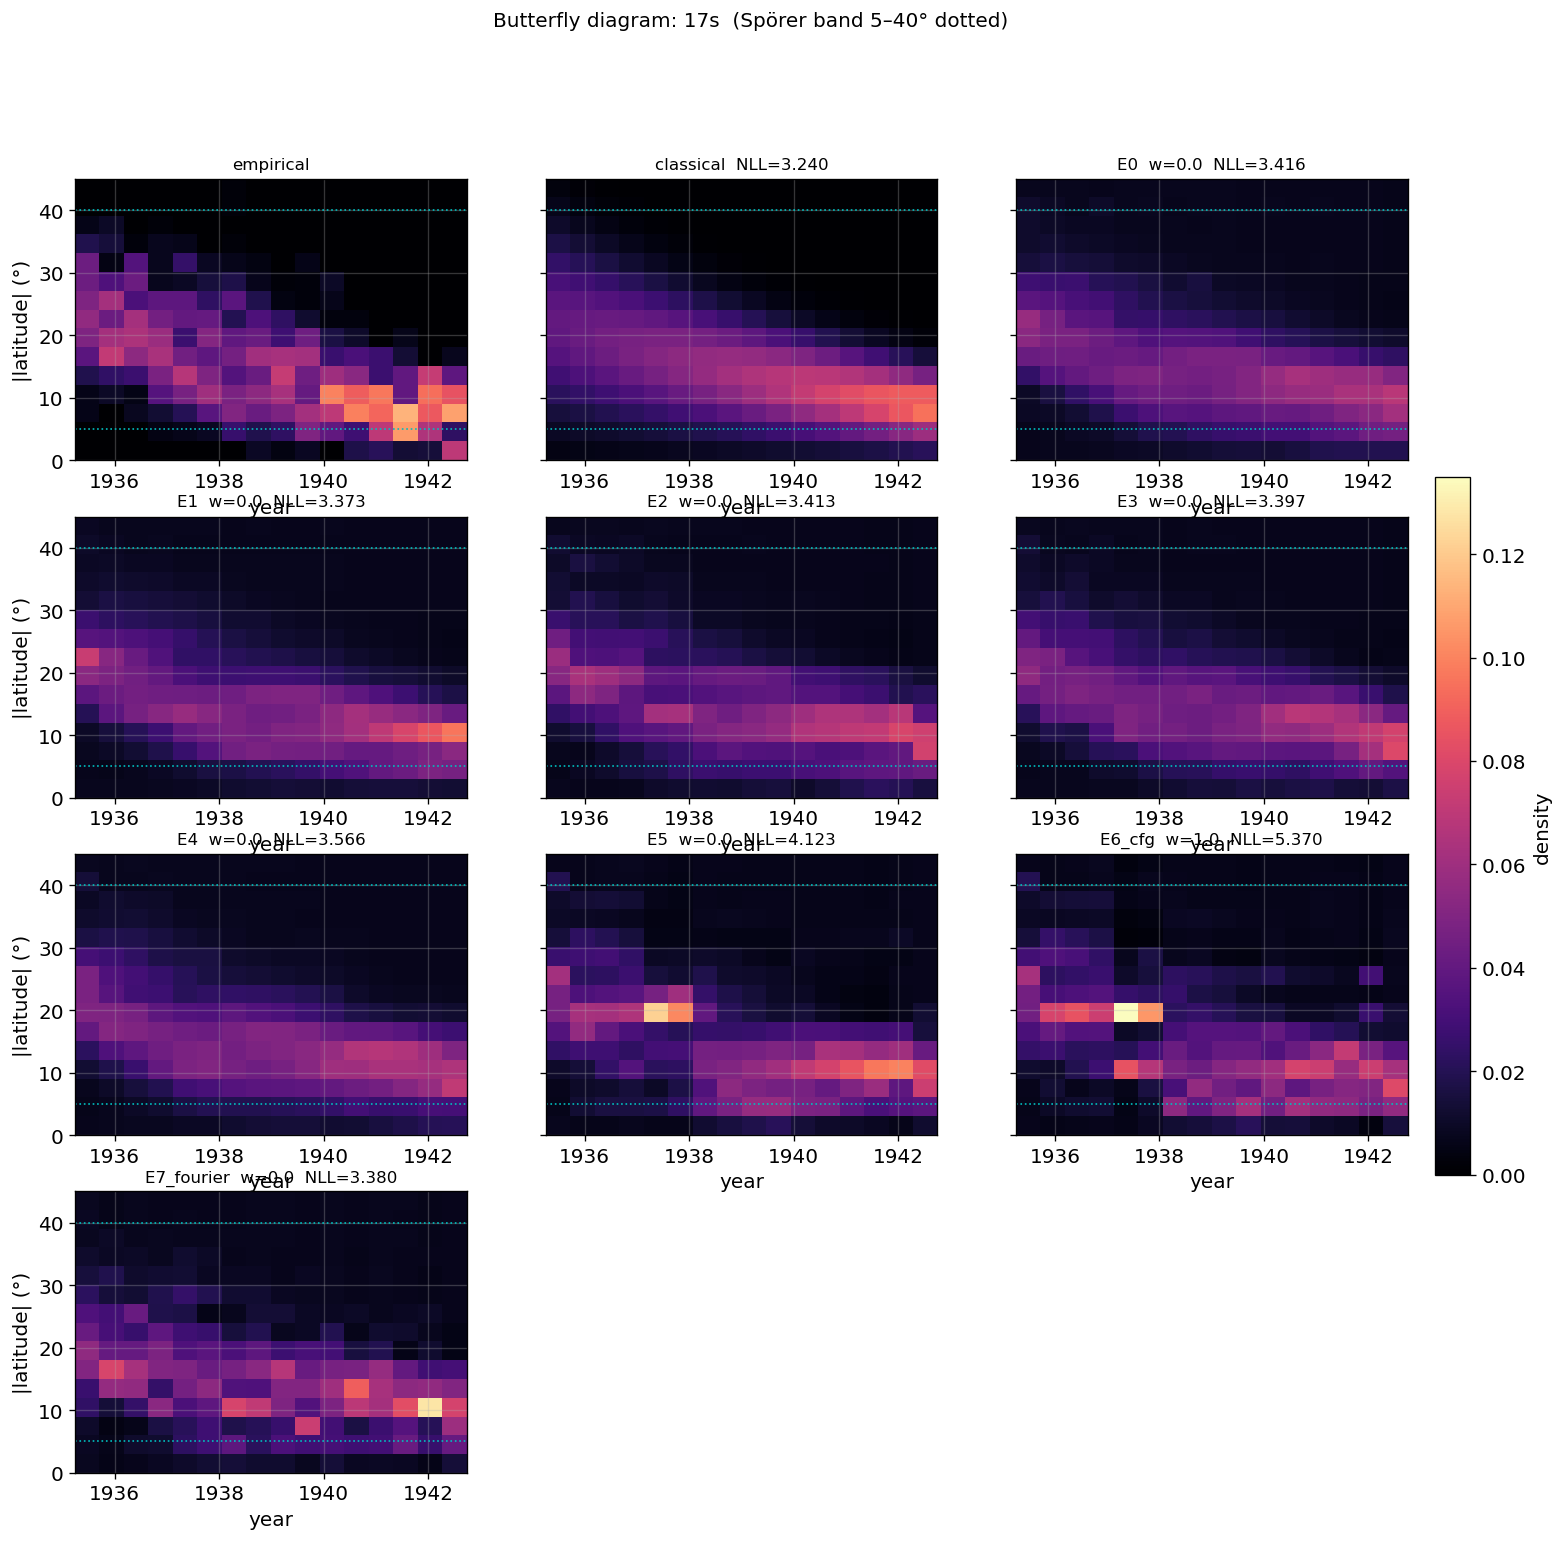


Physical checks for 17s:
       empirical: sporer_slope=-2.187 deg/yr (equatorward=True), in_band=0.881, centroid 23.7->7.7
       classical: sporer_slope=-1.722 deg/yr (equatorward=True), in_band=0.880, centroid 21.7->8.7, NLL=3.240
        E0 w=0.0: sporer_slope=-1.138 deg/yr (equatorward=True), in_band=0.843, centroid 22.2->13.4, NLL=3.416
        E1 w=0.0: sporer_slope=-1.140 deg/yr (equatorward=True), in_band=0.848, centroid 22.3->13.5, NLL=3.373
        E2 w=0.0: sporer_slope=-1.165 deg/yr (equatorward=True), in_band=0.838, centroid 22.4->13.4, NLL=3.413
        E3 w=0.0: sporer_slope=-1.112 deg/yr (equatorward=True), in_band=0.852, centroid 22.5->13.3, NLL=3.397
        E4 w=0.0: sporer_slope=-1.054 deg/yr (equatorward=True), in_band=0.856, centroid 22.6->13.9, NLL=3.566
        E5 w=0.0: sporer_slope=-1.274 deg/yr (equatorward=True), in_band=0.824, centroid 23.0->13.7, NLL=4.123
    E6_cfg w=1.0: sporer_slope=-1.300 deg/yr (equatorward=True), in_band=0.816, centroid 23.1->13.2

In [31]:
if scoreboard.empty:
    print("no scored experiments — nothing to plot")
else:
    # One butterfly per experiment, using its best-NLL row from the scoreboard.
    best_idx_by_exp = scoreboard.groupby("experiment")["nll_direct_mean"].idxmin()
    best_by_exp = scoreboard.loc[best_idx_by_exp].set_index("experiment")

    # Showcase hemicycle: most windows in val.
    hc_show  = max(val_hcs, key=lambda hc: len(hc["blocks"]))
    tag_show = f"{hc_show['cycle']:02d}{hc_show['hemisphere'][0]}"

    def _mean_density(hc, lit_m, train_ds_m, cfg_m, w):
        keys_hc, cond_hc = block_cond_concat([hc], lit_m, cfg_m, train_ds_m)
        cond_K_hc = cond_hc.repeat_interleave(K, dim=0)
        torch.manual_seed(0)
        samp = sample_empirical_extended(
            lit_m, cond_K_hc, guidance_w=w, bin_width=BIN_WIDTH, device=device,
        ).cpu().numpy().reshape(len(keys_hc), K, 15)
        return {key: samp[i].mean(axis=0) for i, key in enumerate(keys_hc)}

    def _bake_butterfly(hc, dens_by_key):
        keys = [(hc["cycle"], hc["hemisphere"], blk["center_decimal"])
                for blk in hc["blocks"]
                if (hc["cycle"], hc["hemisphere"], blk["center_decimal"]) in dens_by_key]
        t  = np.array([k[2] for k in keys], dtype=float)
        m  = np.array([dens_by_key[k] for k in keys], dtype=float)
        return m, t

    # Generate one butterfly per experiment.
    gen_by_exp = {}
    t_ref = None
    for exp_name in best_by_exp.index:
        row = best_by_exp.loc[exp_name]
        cfg_m = EXPERIMENTS_EMP[exp_name]
        w_m = float(row["guidance_w"])
        lit_m, train_ds_m, _, _ = load_trained_empirical_experiment(
            exp_name, cfg_m, windows_aug, classical, BIN_CENTERS,
            CKPT_DIR, alpha_np, sigma_np, bin_width=BIN_WIDTH,
        )
        m, t = _bake_butterfly(hc_show,
                               _mean_density(hc_show, lit_m, train_ds_m, cfg_m, w_m))
        gen_by_exp[exp_name] = (m, t, w_m, float(row["nll_direct_mean"]))
        if t_ref is None or t.size > t_ref.size:
            t_ref = t

    # Empirical density at the shared windows.
    _blk_by_t = {float(b["center_decimal"]): b for b in hc_show["blocks"]}
    emp_show = (np.array([np.histogram(_blk_by_t[t]["lats"], bins=LAT_BINS,
                                       density=True)[0] for t in t_ref])
                if t_ref is not None and t_ref.size else np.empty((0, 15)))

    # Classical butterfly at the same windows: p_cl evaluated at every
    # window center. No gate is applied — matches the all-blocks alignment
    # the experiments and the empirical panel use.
    A_show = hc_show["amplitude"]
    cl_rows = []
    for t in (t_ref if t_ref is not None else []):
        blk = _blk_by_t[t]
        mu  = float(classical.mu(blk["tau"]))
        sig = float(classical.sigma(mu, A_show))
        cl_rows.append(sp_norm.pdf(BIN_CENTERS, loc=mu, scale=sig)
                       if sig > 0 else np.zeros(15))
    cl_show = np.array(cl_rows) if cl_rows else np.empty((0, 15))

    if t_ref is None or t_ref.size == 0:
        print(f"hemicycle {tag_show}: no windows survive the classical gate.")
    else:
        panels = [("empirical", emp_show, t_ref, None, None),
                  ("classical", cl_show, t_ref, None, nll_cl_val)]
        panels += [(name, m, t, w, nll)
                   for name, (m, t, w, nll) in gen_by_exp.items()]

        vmax = max((m.max() for _, m, _, _, _ in panels if m.size), default=1.0)

        n_panels = len(panels)
        ncols = min(3, n_panels)
        nrows = int(np.ceil(n_panels / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows),
                                 sharey=True, squeeze=False)
        axes_flat = axes.flatten()

        for ax, (name, m, t, w, nll) in zip(axes_flat, panels):
            if w is None and nll is None:
                title = name
            elif w is None:
                title = f"{name}  NLL={nll:.3f}"
            else:
                title = f"{name}  w={w:.1f}  NLL={nll:.3f}"
            im = ax.imshow(m.T, origin="lower", aspect="auto", vmin=0, vmax=vmax,
                           extent=[t.min(), t.max(),
                                   LAT_BINS[0], LAT_BINS[-1]], cmap="magma")
            ax.axhline(5, color="c", ls=":", lw=1)
            ax.axhline(40, color="c", ls=":", lw=1)
            ax.set_xlabel("year")
            ax.set_title(title, fontsize=10)
        for ax in axes_flat[len(panels):]:
            ax.axis("off")
        for r in range(nrows):
            axes[r, 0].set_ylabel("|latitude| (°)")

        fig.colorbar(im, ax=axes_flat[:len(panels)].tolist(),
                     fraction=0.025, pad=0.02, label="density")
        fig.suptitle(f"Butterfly diagram: {tag_show}  "
                     f"(Spörer band 5–40° dotted)",
                     fontsize=12)
        plt.show()

        print(f"\nPhysical checks for {tag_show}:")
        print(f"  {'empirical':>14}: ", end="")
        c = butterfly_physical_checks(emp_show, t_ref, BIN_CENTERS)
        print(f"sporer_slope={c['sporer_slope']:+.3f} deg/yr "
              f"(equatorward={c['sporer_ok']}), "
              f"in_band={c['in_band_fraction']:.3f}, "
              f"centroid {c['centroid_start']:.1f}->{c['centroid_end']:.1f}")
        c = butterfly_physical_checks(cl_show, t_ref, BIN_CENTERS)
        print(f"  {'classical':>14}: sporer_slope={c['sporer_slope']:+.3f} deg/yr "
              f"(equatorward={c['sporer_ok']}), "
              f"in_band={c['in_band_fraction']:.3f}, "
              f"centroid {c['centroid_start']:.1f}->{c['centroid_end']:.1f}, "
              f"NLL={nll_cl_val:.3f}")
        for name, (m, t, w, nll) in gen_by_exp.items():
            c = butterfly_physical_checks(m, t, BIN_CENTERS)
            tag = f"{name} w={w:.1f}"
            print(f"  {tag:>14}: sporer_slope={c['sporer_slope']:+.3f} deg/yr "
                  f"(equatorward={c['sporer_ok']}), "
                  f"in_band={c['in_band_fraction']:.3f}, "
                  f"centroid {c['centroid_start']:.1f}->{c['centroid_end']:.1f}, "
                  f"NLL={nll:.3f}")